## LoRA Inference for Stable Diffusion XL

This notebook loads a Stable Diffusion XL base model and your trained LoRA weights from `lora-output-jellyfish` to generate awareness photography images.

Run the cells from top to bottom after your LoRA training has finished.

In [54]:
import torch
from diffusers import AutoencoderKL
from diffusers import StableDiffusionXLPipeline
from matplotlib import pyplot as plt

# Base Stable Diffusion model and LoRA weights directory
base_model = "stabilityai/stable-diffusion-xl-base-1.0"
lora_dir = "/home/ament/Fine_tuning_stable_diffusion/lora-output-March-9-26-sdxl/checkpoint-13500"

# Device and dtype
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Using device: {device}, dtype: {dtype}")

Using device: cuda, dtype: torch.float16


In [61]:
# Load base Stable Diffusion pipeline

pipe = StableDiffusionXLPipeline.from_pretrained(
    base_model,
    torch_dtype=dtype,
    safety_checker=None,
)
pipe = pipe.to(device)

# Load your trained LoRA weights

# weight_name ensures we load the LoRA file (training saves pytorch_lora_weights.safetensors)
pipe.load_lora_weights(lora_dir, weight_name="pytorch_lora_weights.safetensors")

# Optionally fuse LoRA weights for faster inference (if supported)
try:
    pipe.fuse_lora(lora_scale=1.00)
    print("Fused LoRA weights with scale=1.0")
except AttributeError:
    print("Pipeline does not support fuse_lora; using default LoRA scaling.")

Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  4.91it/s]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Fused LoRA weights with scale=1.0


  0%|          | 0/75 [00:00<?, ?it/s]

100%|██████████| 75/75 [01:02<00:00,  1.20it/s]
/home/ament/miniconda3/envs/LOBSTgER/lib/python3.10/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


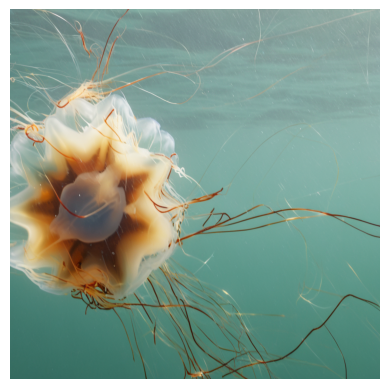

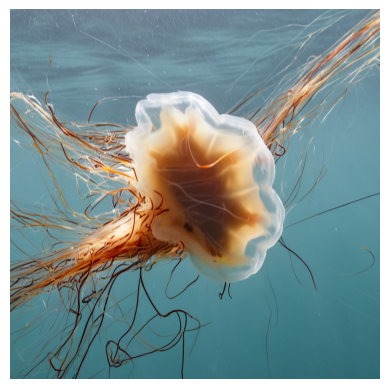

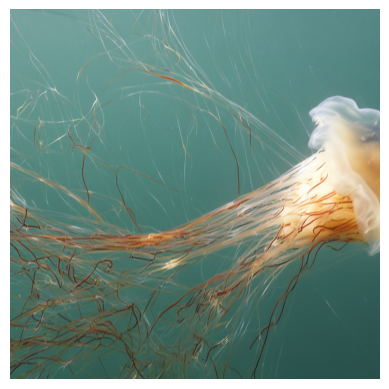

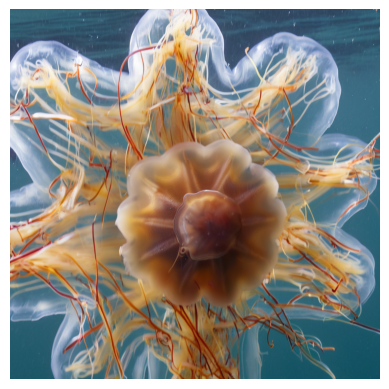

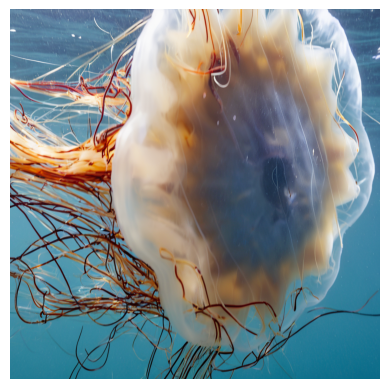

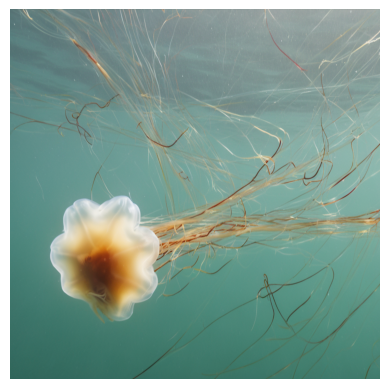

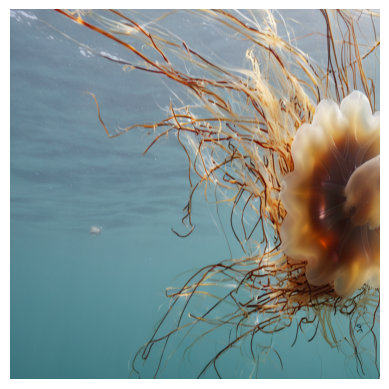

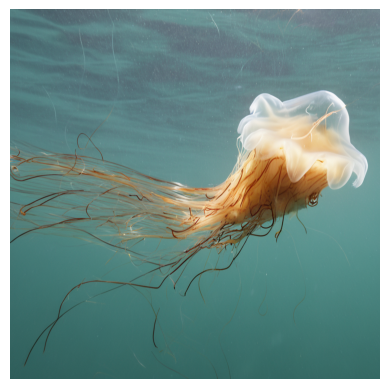

In [65]:
from datetime import datetime

# Prompt tuned to your dataset style
prompt = "image of a Lion's Mane Jellyfish swimming swiftly, high contrast, raw image in 4K, underwater photography in light blue water"
negative_prompt = "low resolution, illustrative, fake, blurry, low quality"

#prompt = "A majestic lion's mane jellyfish, with many entangling tentacles, photo realistic."
#negative_prompt = "The sea surface, the sky, the horizon"

num_images = 8
num_inference_steps = 75
guidance_scale = 7
seed = None

# Set random seed for reproducibility
generator = torch.Generator(device=device)
if seed is not None:
    generator = generator.manual_seed(seed)

pipe.set_progress_bar_config(disable=False)

result = pipe(
    prompt=[prompt] * num_images,
    negative_prompt=[negative_prompt] * num_images if negative_prompt else None,
    num_inference_steps=num_inference_steps,
    guidance_scale=guidance_scale,
    guidance_rescale = 0.7
)

images = result.images

# Display the first image in the notebook
for i in range(num_images):
    plt.imshow(images[i])
    plt.axis('off')
    plt.show()

In [66]:
# Save all generated images to disk
import os

if True:

    output_dir = "lora_inference_images"
    os.makedirs(output_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    for i, img in enumerate(images):
        filename = os.path.join(output_dir, f"lora_sdxl_{timestamp}_{i:02d}.png")
        img.save(filename)
        print(f"Saved image {i} to: {filename}")

Saved image 0 to: lora_inference_images/lora_sdxl_20260309_141823_00.png
Saved image 1 to: lora_inference_images/lora_sdxl_20260309_141823_01.png
Saved image 2 to: lora_inference_images/lora_sdxl_20260309_141823_02.png
Saved image 3 to: lora_inference_images/lora_sdxl_20260309_141823_03.png
Saved image 4 to: lora_inference_images/lora_sdxl_20260309_141823_04.png
Saved image 5 to: lora_inference_images/lora_sdxl_20260309_141823_05.png
Saved image 6 to: lora_inference_images/lora_sdxl_20260309_141823_06.png
Saved image 7 to: lora_inference_images/lora_sdxl_20260309_141823_07.png
